---
title: Bayesian Ridge Regression
---

In [100]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import cvxpy as cp

We shall illustrate Bayesian ridge regression in the context of the following simulation example. There are two choices of the underlying true trend function $f$ in this code. The first choice corresponds to a smooth $f$ while the second choice is more wiggly. 

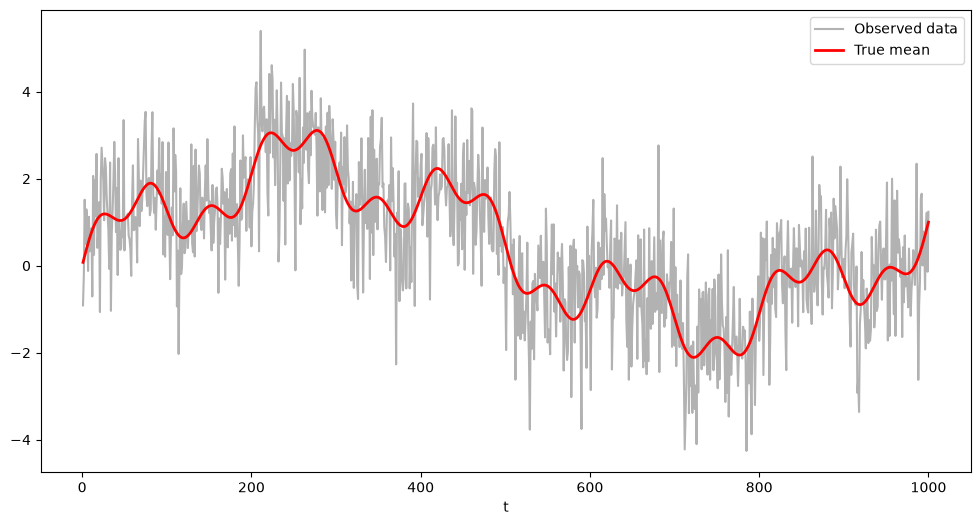

In [124]:
rng = np.random.default_rng(123)

n = 1000
sigma = 1
tvals = np.arange(1, n + 1)

#def f(x): return 2 * np.sin(2 * np.pi * x) + x

def f(x): return (2 * np.sin(2 * np.pi * x) + 0.8 * np.sin(10 * np.pi * x) + 0.4 * np.sin(30 * np.pi * x) + x) 


mu_t = f(tvals / n)
epsilon_t = rng.normal(loc=0, scale=sigma, size=n)
y = mu_t + epsilon_t

plt.figure(figsize=(12, 6))
plt.plot(tvals, y, color="gray", alpha=0.6, label="Observed data")
plt.plot(tvals, mu_t, color="red", linewidth=2, label="True mean")
plt.xlabel("t")
plt.legend()
plt.show()

We will fit our high-dimensional regression model: 
\begin{align*}
  y_t = \beta_0 + \beta_1 (t - 1) + \beta_2 (t - 2)_+ + \dots + \beta_{n-1}(t - (n-1))_+ + \epsilon_t
\end{align*}
to this dataset. This can be written in the usual regression form as $y = X \beta + \epsilon$ with the $X$ matrix calculated as follows. 

In [125]:
n = len(y)
print(n)
x = np.arange(1, n + 1, dtype=float)
knots = np.arange(1, n)                       # c = 1, ..., n-1  (c = 1 gives the x-1 column)
X = np.column_stack([np.ones(n), np.maximum(x[:, None] - knots, 0)])
print(X)

1000
[[  1.   0.   0. ...   0.   0.   0.]
 [  1.   1.   0. ...   0.   0.   0.]
 [  1.   2.   1. ...   0.   0.   0.]
 ...
 [  1. 997. 996. ...   1.   0.   0.]
 [  1. 998. 997. ...   2.   1.   0.]
 [  1. 999. 998. ...   3.   2.   1.]]


Ridge regression is given by the minimizer of: 
\begin{align*}
   \|y - X \beta\|^2 + \lambda \sum_{j=2}^{n-1} \beta_j^2
\end{align*}
where $\lambda$ is the tuning parameter. Small $\lambda$ leads to fitted values close to the data (overfitting) and large $\lambda$ leads to fitted values coming from a straight line (underfitting). 

We can compute the ridge estimator using the formula: $(X^T X + \lambda J)^{-1} X^T y$. Here $J$ is the diagonal matrix with first two diagonal entries 0 and all other diagonal entries equal to 1. 

In [126]:
def solve_ridge_formula(X, y, lambda_val, penalty_start=2):
    n, p = X.shape
    J = np.diag(np.r_[np.zeros(penalty_start), np.ones(p - penalty_start)])
    return np.linalg.solve(X.T @ X + lambda_val * J, X.T @ y)

The following code computes the ridge regression estimator for a given value of $\lambda$.  

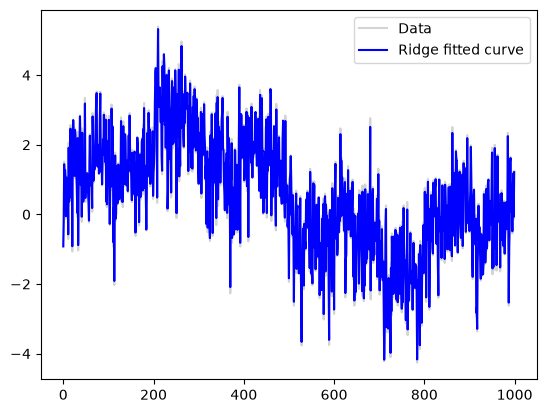

In [128]:
lambda_value = 1e-2
b_ridge = solve_ridge_formula(X, y, lambda_val = lambda_value)
plt.plot(y, color = 'lightgray', label = 'Data')
ridge_fitted = np.dot(X, b_ridge)
plt.plot(ridge_fitted, color = 'blue', label = 'Ridge fitted curve')
plt.legend()
plt.show()

One important aspect in ridge regression is the choice of the regularization parameter $\lambda$. For this, the first step is to identify two values $\lambda_{\min}$ and $\lambda_{\max}$ which serve as the two extreme ends for $\lambda$. When $\lambda = \lambda_{\min}$, the fitted values are basically the same as the raw data, while when $\lambda = \lambda_{\max}$, the fitted values coincide with a simple line fit. 

Using the above code, we can check that when $\lambda = 10^{-2}$, the fitted values are basically the same as the raw data; and when $\lambda = 10^{10}$, the fitted values coincide with linear regression. So we take $\lambda_{\min} := 10^{-2}$ and $\lambda_{\max} = 10^{10}$. 

Then we take a grid of $\lambda$ by taking $\log \lambda$ values to be equally spaced between $\log \lambda_{\min}$ and $\log \lambda_{\max}$. 

In [129]:
lambda_min = 1e-2
lambda_max = 1e10
lambda_candidates =  np.logspace(np.log10(lambda_min), np.log10(lambda_max), num=13)
print(lambda_candidates)

[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07
 1.e+08 1.e+09 1.e+10]


To choose $\lambda$, we used cross-validation (CV) in the last lecture via the following code. 

In [130]:
def ridge_cv(X, y, lambda_candidates):
    n = len(y)
    k = 5
    fold_size = n // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n  # last fold includes remainder
        test_indices = np.arange(start, end)
        train_indices = np.concatenate([np.arange(0, start), np.arange(end, n)])
        folds.append((train_indices, test_indices))

    cv_errors = {lamb: 0 for lamb in lambda_candidates}

    for train_index, test_index in folds:
        X_train = X[train_index]
        X_test = X[test_index]
        y_train = y[train_index]
        y_test = y[test_index]

        for lamb in lambda_candidates:
            beta = solve_ridge_formula(X_train, y_train, lambda_val=lamb)
            y_pred = np.dot(X_test, beta)
            squared_errors = (y_test - y_pred) ** 2
            cv_errors[lamb] += np.sum(squared_errors)

    for lamb in lambda_candidates:
        cv_errors[lamb] /= n

    best_lambda = min(cv_errors, key=cv_errors.get)
    return best_lambda, cv_errors


In [131]:
best_lambda, cv_errors = ridge_cv(X, y, lambda_candidates)
print(best_lambda)
for lamb, error in sorted(cv_errors.items()):
    print(f"Lambda = {lamb:.2f}, CV Error = {error:.6f}")


10000.0
Lambda = 0.01, CV Error = 6832.208809
Lambda = 0.10, CV Error = 3913.131006
Lambda = 1.00, CV Error = 1294.868455
Lambda = 10.00, CV Error = 843.519238
Lambda = 100.00, CV Error = 248.158481
Lambda = 1000.00, CV Error = 38.426146
Lambda = 10000.00, CV Error = 1.984292
Lambda = 100000.00, CV Error = 2.751585
Lambda = 1000000.00, CV Error = 4.226234
Lambda = 10000000.00, CV Error = 4.653630
Lambda = 100000000.00, CV Error = 4.808029
Lambda = 1000000000.00, CV Error = 4.173930
Lambda = 10000000000.00, CV Error = 3.162977


Below we calculate the ridge estimator for $\lambda$ chosen to be the best $\lambda$ given by CV:

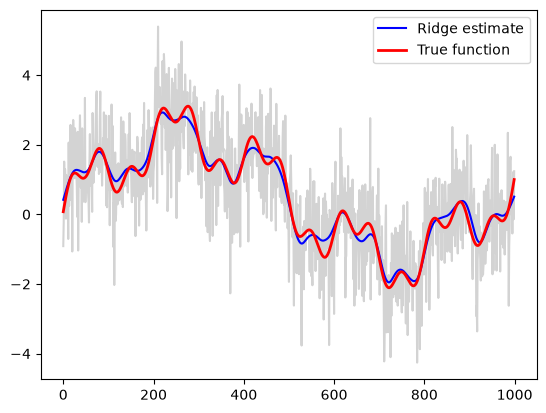

In [132]:
b_ridge = solve_ridge_formula(X, y, lambda_val = best_lambda) 
plt.plot(y, color = 'lightgray')
ridge_fitted = np.dot(X, b_ridge)
plt.plot(ridge_fitted, color = 'blue', label = 'Ridge estimate')
plt.plot(mu_t, color="red", linewidth=2, label="True function")
plt.legend()
plt.show()

Next we shall use Bayesian regularization for selecting $\lambda$. 

### Bayesian Regularization

We work with the following prior: 
\begin{align*}
   \beta_0, \beta_1 \overset{\text{i.i.d}}{\sim} N(0, C) ~~ \text{ and } ~~ \beta_2, \dots, \beta_{n-1} \overset{\text{i.i.d}}{\sim} N(0, \sigma^2/\lambda). 
\end{align*}
We also treat $\sigma$ and $\lambda$ as unknown parameters and assign the prior: 
\begin{align*}
   \lambda \sim f_{\lambda}(\lambda) ~~ \text{ and } ~~ \log \sigma \sim \text{unif}(-C, C)
\end{align*}
where
\begin{align*}
   f_{\lambda}(\lambda) \propto \frac{I(\lambda_{\min} \leq \lambda \leq \lambda_{\max})}{\lambda} ~\text{ which corresponds to}~ \log \lambda \sim \text{unif}(\log \lambda_{\min}, \log \lambda_{\max}). 
\end{align*}
As derived in the lecture, the posterior of $\beta, \sigma, \lambda$ then becomes: 
\begin{align*}
   \beta \mid \text{data}, \sigma, \lambda \sim N\left((X^TX + \lambda J)^{-1} X^T y, \sigma^2 (X^T X + \lambda J)^{-1} \right)
\end{align*}
and
\begin{align*}
   \frac{1}{\sigma^2} \mid \text{data}, \lambda \sim \text{Gamma} \left(\frac{n}{2} - 1, \frac{y^T y - y^T X(X^T X + \lambda J)^{-1} X^T y}{2} \right). 
\end{align*}
and
\begin{align*}
  f_{\lambda\mid\text{data}}(\lambda) \propto f_{\lambda}(\lambda) \frac{\lambda^{(n-2)/2}|X^TX+\lambda J|^{-1/2}}
  {\left(y^Ty-y^TX(X^TX+\lambda J)^{-1}X^Ty\right)^{(n/2)-1}}
\end{align*}
The key here is the posterior for $\lambda$. We compute this posterior numerically below by taking a grid of values for $\log \lambda$. The computation proceeds more stably if we evaluate the posterior density of $\log \lambda$: 
\begin{align*}
   f_{\log \lambda \mid \text{data}}(x) \propto \frac{e^{(n/2 - 1)x} |X^T X + e^x J|^{-1/2}}{\left( y^T y - y^T X (X^TX + e^x J)^{-1} X^T y \right)^{n/2 - 1}} I\{\log \lambda_{\min} \leq x \leq \log \lambda_{\max}\}. 
\end{align*}



In [133]:
n = len(y)
J = np.diag(np.concatenate([[0, 0], np.ones(n - 2)]))
XTX, XTy, yTy = X.T @ X, X.T @ y, y.T @ y

loglambda_gr = np.linspace(np.log(lambda_min), np.log(lambda_max), 1000)
logpost_loglambda = np.zeros(len(loglambda_gr))

for i, ell in enumerate(loglambda_gr):
    if i % 50 == 0: print(i)

    Mat = XTX + np.exp(ell) * J
    beta_mean = np.linalg.solve(Mat, XTy)
    sgn, logdet = np.linalg.slogdet(Mat)

    logpost_loglambda[i] = (
        (n/2-1) * ell
        - 0.5 * logdet
        - (n/2 - 1) * np.log(yTy - XTy.T @ beta_mean)
    )

post_loglambda = np.exp(logpost_loglambda - np.max(logpost_loglambda))

# Probability weights: these sum to 1.
prob_loglambda = post_loglambda / np.sum(post_loglambda)

# Density values: their integral is approximately 1.
step = loglambda_gr[1] - loglambda_gr[0]
post_loglambda = prob_loglambda / step

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


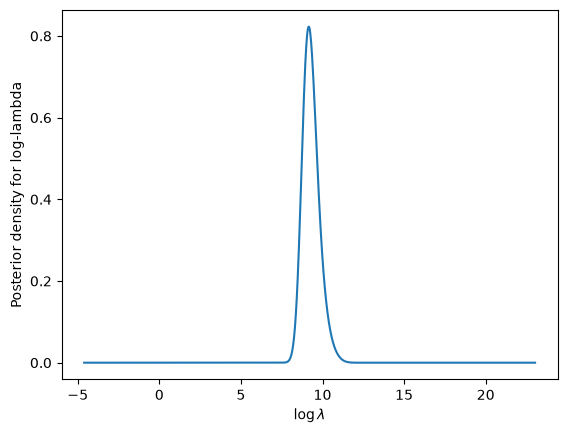

In [134]:
plt.figure()
plt.plot(loglambda_gr, post_loglambda)
plt.xlabel(r"$\log\lambda$")
plt.ylabel("Posterior density for log-lambda")
plt.show()

Take logs with base 10 for better comparison with the previous set of $\lambda$'s.'

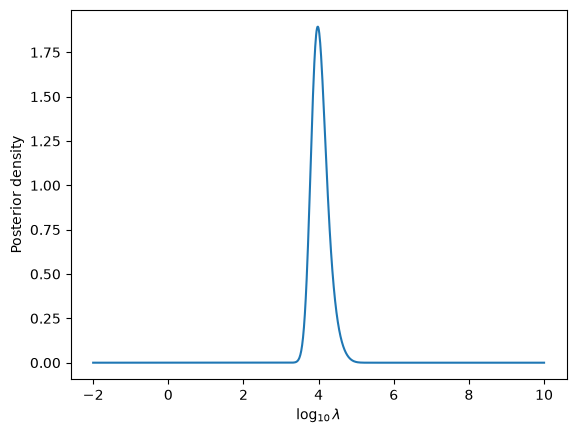

In [135]:
plt.figure()
plt.plot(loglambda_gr / np.log(10), post_loglambda * np.log(10))
plt.xlabel(r"$\log_{10}\lambda$")
plt.ylabel("Posterior density")
plt.show()

Below we compute the posterior mean and median (also uncertainty intervals) for $\lambda$. 

In [136]:
lambda_gr = np.exp(loglambda_gr)

mean_lambda = np.sum(lambda_gr * prob_loglambda)
sd_lambda = np.sqrt(np.sum((lambda_gr - mean_lambda)**2 * prob_loglambda))
mode_lambda = lambda_gr[np.argmax(prob_loglambda / lambda_gr)]

cdf_lambda = np.cumsum(prob_loglambda)
lower, median_lambda, upper = lambda_gr[
    np.searchsorted(cdf_lambda, [0.025, 0.5, 0.975])
]

print(f"Posterior mean: {mean_lambda:.3e}")
print(f"Posterior standard deviation: {sd_lambda:.3e}")
print(f"Posterior mode (grid approximation): {mode_lambda:.3e}")
print(f"Posterior median: {median_lambda:.3e}")
print(f"95% credible interval: ({lower:.3e}, {upper:.3e})")

Posterior mean: 1.275e+04
Posterior standard deviation: 8.549e+03
Posterior mode (grid approximation): 7.905e+03
Posterior median: 1.042e+04
95% credible interval: (4.546e+03, 3.520e+04)


Below we compute the regression fitted values when $\lambda$ is chosen to be the posterior mean and median.

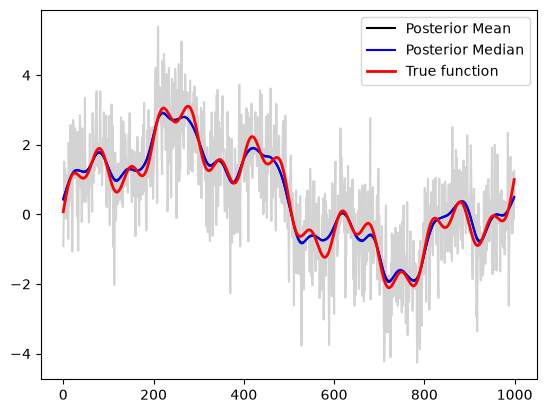

In [137]:
b_ridge_mean = solve_ridge_formula(X, y, lambda_val = mean_lambda)
b_ridge_median = solve_ridge_formula(X, y, lambda_val = median_lambda)
plt.plot(y, color = 'lightgray')
ridge_fitted_mean = np.dot(X, b_ridge_mean)
ridge_fitted_median = np.dot(X, b_ridge_median)
plt.plot(ridge_fitted_mean, color = 'black', label = 'Posterior Mean')
plt.plot(ridge_fitted_median, color = 'blue', label = 'Posterior Median')
plt.plot(mu_t, color="red", linewidth=2, label="True function")
#plt.plot(ridge_fitted, color = 'green', linewidth = 2, label = 'Ridge (CV)')
plt.legend()
plt.show()

Below we run full Bayesian inference by selecting $N = 1000$ posterior samples. 

In [138]:
N = 1000
n = len(y)

J = np.diag(np.concatenate([[0, 0], np.ones(n - 2)]))
XTX, XTy, yTy = X.T @ X, X.T @ y, y.T @ y
shape = n/2 - 1

loglambda_samples = np.random.choice(
    loglambda_gr, size=N, p=prob_loglambda
)
lambda_samples = np.exp(loglambda_samples)

sig_samples = np.zeros(N)
betahats = np.zeros((n, N))
muhats = np.zeros((n, N))

for i in range(N):
    if i % 50 == 0: print(i)

    lam = lambda_samples[i]
    Mat = XTX + lam * J
    beta_mean = np.linalg.solve(Mat, XTy)

    # Sample sigma: numpy uses the Gamma shape and scale.
    rate = (yTy - XTy.T @ beta_mean) / 2
    sig = np.sqrt(1 / np.random.gamma(shape, 1/rate))
    sig_samples[i] = sig

    # Sample beta with covariance sig**2 * Mat^{-1}.
    L = np.linalg.cholesky(Mat)
    betahat = beta_mean + sig * np.linalg.solve(L.T, np.random.randn(n))

    betahats[:, i] = betahat
    muhats[:, i] = X @ betahat

beta_est = np.mean(betahats, axis=1)
mu_est = np.mean(muhats, axis=1)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


The posterior samples corresponding to the fitted curves are plotted below. Here by fitted curve, we mean: 
\begin{align*}
  \mu_t^{(i)} = \beta^{(i)}_0 + \beta^{{i}}_1 (t - 1) + \sum_{j=2}^{n-1} \beta^{(i)}_j(t - j)_+
\end{align*}
where $\beta^{(i)}_j, j = 0, 1, \dots, n-1$ is the $i$-th posterior sample. 

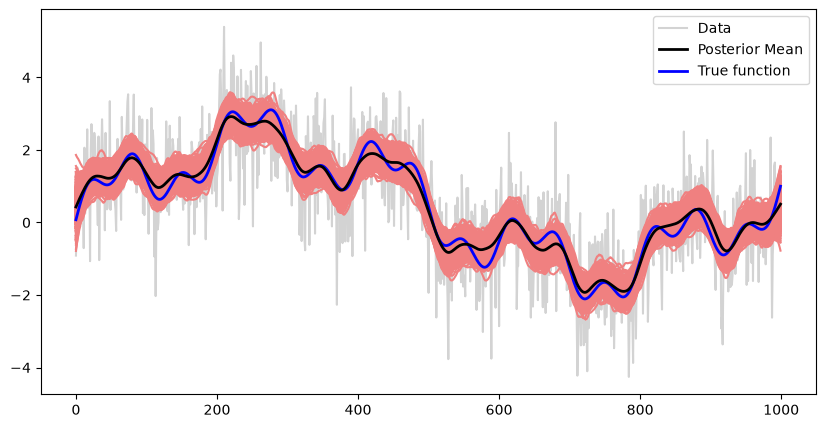

In [139]:
plt.figure(figsize=(10, 5))

plt.plot(y, label="Data", color="lightgray", zorder=1)

for i in range(N):
    plt.plot(muhats[:, i], color="lightcoral", zorder=2)

plt.plot(mu_est, color="black", linewidth=2,
         label="Posterior Mean", zorder=3)
plt.plot(mu_t, color="blue", linewidth=2, label="True function")

plt.legend()
plt.show()

The above plot gives an indication of the uncertainty present in the $\beta$ estimates. 

The following is the histogram of $\sigma$ values.

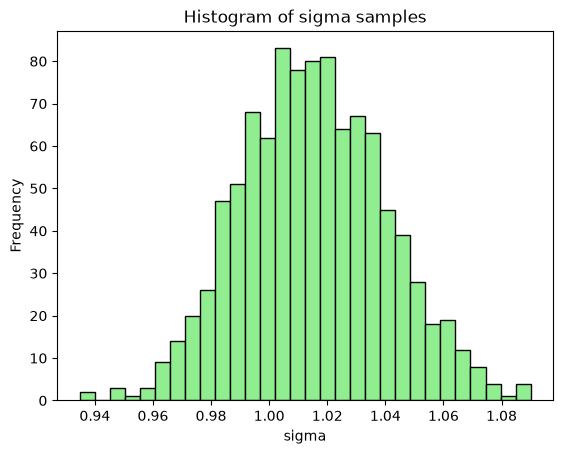

In [140]:
plt.hist(sig_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of sigma samples')
plt.xlabel('sigma')
plt.ylabel('Frequency')
plt.show()